# **Data Extraction Tool**
<font color="#FBB800">Agricultural Cold Chain Access Planning (AgCAP) Tool</font><br>

-------
# Description
The main purpose of this notebook is to calculate the agriculture and cooling-related metrics to obtain the final dataset to visualize. <br>
It takes as input the raw data stored inside each sub-folder in the `data/raw` directory, after download and - if necessary - due pre-processing, and performs the following operations:
1) Read and transform the raw input data the 
2) Clean, transform and extract the raw data into the settlement dataset
3) Perform data integrity checks and formatting
4) Export the processed data to be ingested by the **Core analysis Tool**


-------
# License and Copyright Notice

This notebook is part of the **AgCAP** project.

**Copyright (C) 2025 Sustainable Energy for All**

This program is free software: you can redistribute it and/or modify it under the terms of the **GNU Affero General Public License version 3 (AGPLv3)** as published by the Free Software Foundation.

This work is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU Affero General Public License for more details.

You should have received a copy of the GNU Affero General Public License along with this program. If not, see <https://www.gnu.org/licenses/agpl-3.0.html>.

**[Optional: Add a link to source code archive for AGPL compliance]**
*Download Source Code for this Version:* [Link to GitHub Tag Archive]

In [26]:
# Copyright (C) 2025 Sustainable Energy for All
#
#This program is free software: you can redistribute it and/or modify it 
# under the terms of the **GNU Affero General Public License version 3 (AGPLv3)** 
# as published by the Free Software Foundation.
#
# See <https://www.gnu.org/licenses/agpl-3.0.html>.

# Setup, data import and preparation

## Import packages and functions

In [98]:
import sys
from pathlib import Path
import numpy as np
from datetime import datetime
from rasterstats import zonal_stats

# Load the autoreload extension
%load_ext autoreload
%autoreload 2

current_dir = Path.cwd()
project_root = current_dir.parent

# Insert the project root path into the system path, allowing the notebook to find the 'scripts' folder as a package.
sys.path.insert(0, str(project_root))

# Import functions
from scripts.functions import *
from scripts.app import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Setting the target coordinate system (Mandatory)

When calculating distances it is important to choose a coordinate system that represents distances correctly in your area of interst. The coordinate system that is given below is the World Mercator, these coordinate system works well for Sub Saharan Africa but the distortions get larger as you move away from the equator.

In order to select your own coordinate system go to [epsg.io](http://epsg.io/) and type in your area of interest, this will give you a list of coordinate systems to choose from. Once you have selected your coordinate system replace the numbers below with the numbers from your coordinate system **(keep the "EPSG" part)**.

**NOTE** When selecting your coordinate system make sure that you select a system with the unit of meters, this is indicated for all systems on [epsg.io](http://epsg.io/)

In [28]:
## Coordinate and projection systems
crs_WGS84 = pyproj.CRS("EPSG:4326")    # Originan WGS84 coordinate system
crs_proj = pyproj.CRS("EPSG:29702")    # Projection system for the selected country -- see http://epsg.io/ for more info 
##"EPSG:29702":Laborde Oblique Mercator is the national standard projected CRS for Madagascar

## Define workspace and main directories

The notebook reads data files dropped in the respective sub-directories inside *data/raw/[data_name]/input_file* <br>
Make sure to have only one file inside, otherwise an error will be raised

In [29]:
# --- MASTER EXTENSION LISTS ---
# Vector/Table Geo-data
MASTER_VECTOR_EXTENSIONS = ['gpkg', 'geojson', 'fgb', 'parquet', 'shp', 'json', 'csv','customization']
# Raster Data
MASTER_RASTER_EXTENSIONS = ['tif', 'tiff']

In [30]:
# --- ADMIN FILES ---
adm0_path= get_single_input_file_path(project_root/'data/raw/admin/adm0/input_file', 
                                       allowed_extensions=MASTER_VECTOR_EXTENSIONS)
adm1_path= get_single_input_file_path(project_root/'data/raw/admin/adm1/input_file', 
                                       allowed_extensions=MASTER_VECTOR_EXTENSIONS)
adm2_path= get_single_input_file_path(project_root/'data/raw/admin/adm2/input_file', 
                                       allowed_extensions=MASTER_VECTOR_EXTENSIONS)
adm3_path= get_single_input_file_path(project_root/'data/raw/admin/adm3/input_file', 
                                       allowed_extensions=MASTER_VECTOR_EXTENSIONS)
adm4_path= get_single_input_file_path(project_root/'data/raw/admin/adm4/input_file', 
                                       allowed_extensions=MASTER_VECTOR_EXTENSIONS)

# --- RASTER AND SPECIFIC FILES ---
# Aridity
aridity_path = get_single_input_file_path(
    project_root/'data/raw/aridity_index/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# Climatic classification
clim_class_path = get_single_input_file_path(
    project_root/'data/raw/clim_class/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# Conflict
conflict_path = get_single_input_file_path(
    project_root/'data/raw/conflict/input_file',
    allowed_extensions=MASTER_VECTOR_EXTENSIONS
)
# Crop Production folder
crop_prod_folder_path = project_root/'data/raw/crop_prod_spam/input_file'

# Cropland
cropland_path = get_single_input_file_path(
    project_root/'data/raw/cropland/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# Cyclone Hazard
cycl_haz_path = get_single_input_file_path(
    project_root/'data/raw/cyclone_hazard/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# Diurnal Range
diurnal_range_path = get_single_input_file_path(
    project_root/'data/raw/diurn_range/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# Elevation
elevation_path = get_single_input_file_path(
    project_root/'data/raw/elevation/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# Food_Security
food_sec_path = get_single_input_file_path(
    project_root/'data/raw/food_security/input_file',
    allowed_extensions=MASTER_VECTOR_EXTENSIONS
)
# Hot Days 30
hot_days_path = get_single_input_file_path(
    project_root/'data/raw/hot_days_30/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# Relative Humidity
rel_humidity_path = get_single_input_file_path(
    project_root/'data/raw/relative_humidity/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# IEP electrification status results
IEP_elec_path = get_single_input_file_path(
    project_root/'data/raw/iep_elec_results/input_file',
    allowed_extensions=MASTER_VECTOR_EXTENSIONS
)
# Livelihood_Zones
livel_path = get_single_input_file_path(
    project_root/'data/raw/livelihood_zones/input_file',
    allowed_extensions=MASTER_VECTOR_EXTENSIONS
)
# Mini_Grids
minigrids_path = get_single_input_file_path(
    project_root/'data/raw/mini_grids/input_file',
    allowed_extensions=MASTER_VECTOR_EXTENSIONS
)
# MV_lines
MVlines_path = get_single_input_file_path(
    project_root/'data/raw/mv_lines/input_file',
    allowed_extensions=MASTER_VECTOR_EXTENSIONS
)
# Nightlight
nightlights_path = get_single_input_file_path(
    project_root/'data/raw/nightlight/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# Population
pop_path = get_single_input_file_path(
    project_root/'data/raw/population/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# Precipitation
precipitation_path = get_single_input_file_path(
    project_root/'data/raw/precipitation/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# pvout
pvout_path = get_single_input_file_path(
    project_root/'data/raw/pvout/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# rwi
rwi_path = get_single_input_file_path(
    project_root/'data/raw/rwi/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# Settlements
settles_path = get_single_input_file_path(
    project_root/'data/raw/settlements/input_file',
    allowed_extensions=MASTER_VECTOR_EXTENSIONS
)
# Shoreline
shorelines_path = get_single_input_file_path(
    project_root/'data/raw/shoreline/input_file',
    allowed_extensions=MASTER_VECTOR_EXTENSIONS
)
# Travel times
tt_airports_path = get_single_input_file_path(
    project_root/'data/raw/t_time/input_air',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
tt_ports_path = get_single_input_file_path(
    project_root/'data/raw/t_time/input_ports',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
tt_capital_path = get_single_input_file_path(
    project_root/'data/raw/t_time/input_capital',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
tt_cities_path = get_single_input_file_path(
    project_root/'data/raw/t_time/input_cities',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
tt_railways_path = get_single_input_file_path(
    project_root/'data/raw/t_time/input_railways',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# Temperature
temperature_annual_avg_path = get_single_input_file_path(
    project_root/'data/raw/temperature/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)
# Water_Occurance
water_occurrance_path = get_single_input_file_path(
    project_root/'data/raw/w_occ/input_file',
    allowed_extensions=MASTER_RASTER_EXTENSIONS
)

## Importing admin boundary as geodataframe
For the administrative boundaries you will have to select a **Polygon** layer represeting your area of interest.

In [31]:
#Select layer (if multiple layers in gpkg), name of column containing adm unit to select, and adm unit to select
adm_col_name="ADM0_EN"
adm_unit_name="Madagascar"

# Create a new geo-dataframe
admin_gdf = gpd.read_file(adm0_path)
admin_gdf = admin_gdf[admin_gdf[adm_col_name] == adm_unit_name]

## Add buffer for clipping
## cap_style refers to the type of geometry generated; 3=rectangular (see shapely documectation for more info -- https://shapely.readthedocs.io/en/stable/manual.html)
admin_gdf_buf = admin_gdf.copy()
admin_gdf_buf['geometry'] = admin_gdf_buf.apply(lambda x:
                                        x.geometry.buffer(0.008, cap_style=3), axis=1)  ### 0.008 deg = ~1km

In [32]:
# Plot adm unit of analysis (image)
#admin_gdf_buf.plot()

In [33]:
##Import all other admin boundaries
adm0_gdf =gpd.read_file(adm0_path)
adm1_gdf =gpd.read_file(adm1_path)
adm2_gdf =gpd.read_file(adm2_path)
adm3_gdf =gpd.read_file(adm3_path)
adm4_gdf =gpd.read_file(adm4_path)

## Define the target locations (settlements/clusters)

Select the settlements to be used in the analysis

In [34]:
## Read settlements as gdf
settles_gdf_all = gpd.read_file(settles_path)

In [35]:
settles_gdf_all.columns

Index(['OBJECTID', 'country', 'iso3', 'building_count', 'building_area',
       'type', 'probability', 'date', 'source', 'mgrs_code', 'geometry'],
      dtype='object')

In [36]:
#Exclude hamlets (for GRID3 data only)
settles_gdf=settles_gdf_all[settles_gdf_all['type']!='Hamlet']

In [37]:
##Activate this if you want to drop certain columns (dependingn on the source of data this may vary)
settles_gdf['id'] = settles_gdf['OBJECTID']
settles_gdf = settles_gdf.drop(["country", "iso3", "probability", "date", "source", "mgrs_code",'OBJECTID','building_area'],axis=1)


In [38]:
print("Repairing invalid geometries...")
# .buffer(0) is a standard technique to use GEOS topology to fix self-intersections
settles_gdf_all['geometry'] = settles_gdf_all.geometry.buffer(0)

Repairing invalid geometries...


Filter out clusters with less than XXX buildings (if this attribute is available)

In [39]:
buildings_threshold=100
small_settles_perc= (len(settles_gdf) )/(settles_gdf['building_count']<buildings_threshold).sum()
print(f'Percentage of settlements with less than {buildings_threshold} buildings: {small_settles_perc.round(1)} %')

Percentage of settlements with less than 100 buildings: 1.9 %


In [40]:
## If building count is an object you can use his to filter
""" settles_gdf = settles_gdf[(settles_gdf["bld_count"] == '101-250') | 
                          (settles_gdf["bld_count"] == '251-1000') | 
                          (settles_gdf["bld_count"] == '1001 and up')] """

#If building count is numeric you can use his to filter
settles_gdf = settles_gdf[settles_gdf["building_count"] >= 100]

In [41]:
settles_gdf['building_count']=settles_gdf['building_count'].round(0).astype('Int64')

In [42]:
#settles_gdf.plot()

Simplify geometry

In [43]:
#Simplify geometries (optional)

# settles_gdf = gpd.read_file("Output/settles_gdf_MDG_analyzed.gpkg")
settles_gdf_simpl = settles_gdf.copy()
settles_gdf_simpl=settles_gdf_simpl.to_crs(crs_proj)

# Simplify polygons using a tolerance of 5 (assuming the CRS units are meters)
settles_gdf_simpl['geometry'] = settles_gdf_simpl['geometry'].simplify(tolerance=5, preserve_topology=True)
settles_gdf_simpl=settles_gdf_simpl.to_crs(crs_WGS84)
settles_gdf= settles_gdf_simpl

Calculate settlements' area in km2

In [44]:
settles_gdf_proj = settles_gdf.to_crs(crs_proj)
settles_gdf['settl_area_km2'] = settles_gdf_proj.geometry.area / 1e6

The user need to replace the names of the administrative levels in the code below.

In [45]:
## Extract admin 1 name | Note that you need to specify the column containing the admin 1 names, and the name of the admin unit
settles_gdf = get_admin_name(settles_gdf, adm1_gdf, "ADM1_EN")
settles_gdf.rename(columns={'ADM1_EN': 'Region'}, inplace=True)

## Extract admin 2 name | Note that you need to specify the column containing the admin 2 names, and the name of the admin unit
settles_gdf = get_admin_name(settles_gdf, adm2_gdf, "ADM2_EN")
settles_gdf.rename(columns={'ADM2_EN': 'District'}, inplace=True)

## Extract admin 3 name | Note that you need to specify the column containing the admin 3 names, and the name of the admin unit
settles_gdf = get_admin_name(settles_gdf, adm3_gdf, "ADM3_EN")
settles_gdf.rename(columns={'ADM3_EN': 'Commune'}, inplace=True)

## Extract admin 4 name | Note that you need to specify the column containing the admin 4 names, and the name of the admin unit
settles_gdf = get_admin_name(settles_gdf, adm4_gdf, "ADM4_EN")
settles_gdf.rename(columns={'ADM4_EN': 'Fokontany'}, inplace=True)

2025-12-07 18:15:45.153043
2025-12-07 18:15:45.685016
2025-12-07 18:15:45.844676
2025-12-07 18:15:45.935459


Plot settlements (optional)

In [46]:
# # Create the axis first
# fig, ax = plt.subplots(figsize=(10, 10))
# admin_gdf.plot(ax=ax, edgecolor='black', alpha=0.2)
# settles_gdf.plot(ax=ax, legend=True, markersize=3, figsize=(15, 15), alpha=0.5)
# ax.set_aspect('equal', 'box')
# #txt = ax.set_title("{}'s Administrative Boundary".format(admin_gdf.ADM1_EN.unique()[0]))

# Population

### Raster population to settlements
First the exact population count into the settlements

In [47]:
col_name = 'pop_2025'
method = 'sum'
path= pop_path

settles_gdf = run_zonal_stats_clipped(
    polygons_gdf=settles_gdf,
    raster_path=path,
    stats=method,
    col_prefix=col_name,
    fill_na=None
)
# Round and convert to int, handling possible NaNs by filling with 0
settles_gdf[col_name] = settles_gdf[col_name].fillna(0).round().astype(int)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")

Calculating raster window and reading only relevant data...
Data array shape read: (16221, 8699)
Running zonal statistics on the clipped array...
Number of NaNs: 0


In [48]:
#Print stats on population, to validate if there are inconsistencies
pop_MADA=zonal_stats(adm0_gdf.geometry,pop_path,stats=['sum'], geojson_out=False, all_touched=True )[0]['sum']
pop_admin=zonal_stats(admin_gdf.geometry,pop_path,stats=['sum'], geojson_out=False, all_touched=True )[0]['sum']
pop_BUA=settles_gdf.loc[settles_gdf['type']=='Built-up Area', 'pop_2025'].sum()
pop_SSA=settles_gdf.loc[settles_gdf['type']=='Small Settlement Area', 'pop_2025'].sum()


print('According to the population raster:')
print(f'Population in the Country= {pop_MADA}')
print(f'Population in the study area ({adm_unit_name})= {pop_admin} ({round(pop_admin/pop_MADA*100,2)}%)')
print('Of which:')
print(f'Population in Built-up Areas in {adm_unit_name}= {pop_BUA} ({round(pop_BUA/pop_admin*100,2)}%)')
print(f'Population in Small Settlement Area in {adm_unit_name}= {pop_SSA} ({round(pop_SSA/pop_admin*100,2)}%)')
print(f'The rest is located in filtered settlements (Small hamlets or the ones with too little buildings, not considered for project implementation)')

According to the population raster:
Population in the Country= 32335628.0
Population in the study area (Madagascar)= 32335628.0 (100.0%)
Of which:
Population in Built-up Areas in Madagascar= 6050293 (18.71%)
Population in Small Settlement Area in Madagascar= 6611425 (20.45%)
The rest is located in filtered settlements (Small hamlets or the ones with too little buildings, not considered for project implementation)


### Population density

,building_count,type,geometry,id,Region,District,Commune,Fokontany,pop_2025,pop_dens_pp_km2
0,293,Small Settlement Area,"POLYGON ((49.23371 -12.05675, 49.23544 -12.056...",24,Diana,Antsiranana II,Andranovondronina,Andranovondronina,166,1075
1,120,Small Settlement Area,"POLYGON ((49.28204 -12.06508, 49.28243 -12.064...",41,Diana,Antsiranana II,Andranovondronina,Bedarabe,79,774
2,936,Small Settlement Area,"POLYGON ((49.34287 -12.25508, 49.34376 -12.255...",118,Diana,Antsiranana II,Ramena,Ramena,1762,1762
3,115,Small Settlement Area,"POLYGON ((49.44204 -12.38425, 49.44324 -12.384...",173,Diana,Antsiranana II,Mahavanona,Ambodivahibe,90,561
4,254,Small Settlement Area,"POLYGON ((49.51328 -12.4526, 49.51293 -12.4524...",253,Diana,Antsiranana II,Andrafiabe,Ambolobozokely,212,612
...,...,...,...,...,...,...,...,...,...,...
14717,131,Small Settlement Area,"POLYGON ((46.67592 -23.74879, 46.67593 -23.747...",525370,Atsimo Atsinanana,Befotaka,Ranotsara Sud,Ampatramary,226,1505
14718,101,Small Settlement Area,"POLYGON ((46.25954 -24.21758, 46.25992 -24.217...",525372,Anosy,Amboasary-Atsimo,Mahaly,Adabolava Sud,140,2208
14719,123,Small Settlement Area,"POLYGON ((46.09037 -24.08591, 46.09077 -24.085...",525404,Anosy,Amboasary-Atsimo,Tsivory,Tsilanja,367,2032
14720,150,Small Settlement Area,"POLYGON ((46.5887 -22.67841, 46.59044 -22.6784...",525418,Ihorombe,Iakora,Ranotsara Nord,Bekatra Tsarahonenana,176,1561


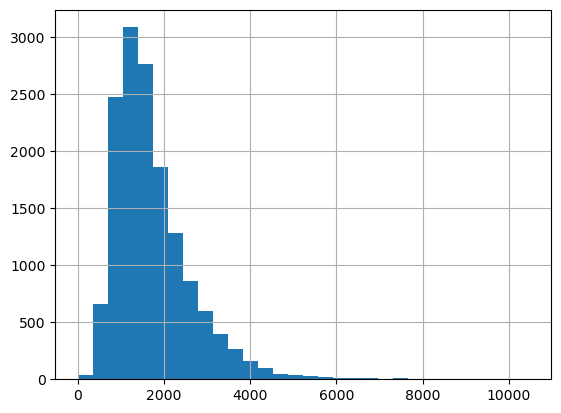

In [49]:
settles_gdf["pop_dens_pp_km2"]=(settles_gdf["pop_2025"]/settles_gdf["settl_area_km2"]).astype(int)
settles_gdf["pop_dens_pp_km2"].hist(bins=30)

settles_gdf.drop(columns={"settl_area_km2"})

### Population aggregation within 20km buffer area

Then the population sum within 20km from the cluster

In [50]:
print("Creating 20km buffers...")
settles_buffer_temp = settles_gdf[['id', 'geometry']].to_crs(crs_proj).copy()

# Apply the 20km buffer (20000 meters)
settles_buffer_temp['geometry'] = settles_buffer_temp.geometry.buffer(20000)

settles_buffer_temp = run_zonal_stats_clipped(
    polygons_gdf=settles_buffer_temp,
    raster_path=pop_path,
    stats='sum',
    col_prefix='pop_20km',
    fill_na=0
)


col_name = 'pop_20km_sum' # The function appends '_sum' to the prefix
if 'pop_20km' in settles_buffer_temp.columns: # Handle case where stat name isn't appended
    col_name = 'pop_20km'

# Round and Convert to Int
settles_buffer_temp['pop_20km_final'] = settles_buffer_temp[col_name].fillna(0).round().astype(int)

# Merge results back to the original settlements layer
settles_gdf = settles_gdf.merge(
    settles_buffer_temp[['id', 'pop_20km_final']], 
    on='id', 
    how='left'
)

# Rename to standard name
settles_gdf.rename(columns={'pop_20km_final': 'pop_20km'}, inplace=True)

# Validation
print(f"20km Population buffer calculated.")
print(f"NaNs: {settles_gdf['pop_20km'].isnull().sum()}")
print(f"Mean Pop 20km: {settles_gdf['pop_20km'].mean()}")

# Clean up memory
del settles_buffer_temp

#reproject back 
settles_gdf.to_crs(crs_WGS84)

Creating 20km buffers...
Calculating raster window and reading only relevant data...
Data array shape read: (16388, 8757)
Running zonal statistics on the clipped array...
20km Population buffer calculated.
NaNs: 0
Mean Pop 20km: 180716.90368156502


,building_count,type,geometry,id,settl_area_km2,Region,District,Commune,Fokontany,pop_2025,pop_dens_pp_km2,pop_20km
0,293,Small Settlement Area,"POLYGON ((49.23371 -12.05675, 49.23544 -12.056...",24,0.154384,Diana,Antsiranana II,Andranovondronina,Andranovondronina,166,1075,64610
1,120,Small Settlement Area,"POLYGON ((49.28204 -12.06508, 49.28243 -12.064...",41,0.102011,Diana,Antsiranana II,Andranovondronina,Bedarabe,79,774,8188
2,936,Small Settlement Area,"POLYGON ((49.34287 -12.25508, 49.34376 -12.255...",118,0.999533,Diana,Antsiranana II,Ramena,Ramena,1762,1762,26069
3,115,Small Settlement Area,"POLYGON ((49.44204 -12.38425, 49.44324 -12.384...",173,0.160230,Diana,Antsiranana II,Mahavanona,Ambodivahibe,90,561,7728
4,254,Small Settlement Area,"POLYGON ((49.51328 -12.4526, 49.51293 -12.4524...",253,0.346018,Diana,Antsiranana II,Andrafiabe,Ambolobozokely,212,612,3628
...,...,...,...,...,...,...,...,...,...,...,...,...
14717,131,Small Settlement Area,"POLYGON ((46.67592 -23.74879, 46.67593 -23.747...",525370,0.150090,Atsimo Atsinanana,Befotaka,Ranotsara Sud,Ampatramary,226,1505,38794
14718,101,Small Settlement Area,"POLYGON ((46.25954 -24.21758, 46.25992 -24.217...",525372,0.063394,Anosy,Amboasary-Atsimo,Mahaly,Adabolava Sud,140,2208,36251
14719,123,Small Settlement Area,"POLYGON ((46.09037 -24.08591, 46.09077 -24.085...",525404,0.180522,Anosy,Amboasary-Atsimo,Tsivory,Tsilanja,367,2032,44685
14720,150,Small Settlement Area,"POLYGON ((46.5887 -22.67841, 46.59044 -22.6784...",525418,0.112724,Ihorombe,Iakora,Ranotsara Nord,Bekatra Tsarahonenana,176,1561,39482


# Electrification status

### Getting distance to nearest MV line

In [51]:
settles_gdf_copy=settles_gdf
settles_gdf_copy=distance_from_lines("MV_lines", admin_gdf, crs_proj, settles_gdf, MVlines_path)
settles_gdf= settles_gdf_copy

--- Starting analysis for MV_lines at 2025-12-07 18:17:46.175140 ---
Preparing settlements...
Reading and processing lines...
Discretizing lines into points (100m intervals)...
Running KDTree algorithm...
Checking for exact physical overlaps...
--- Finished MV_lines. Duration: 0:03:30.599000 ---


### Getting distance to nearest (existing) mini grids

In [52]:
settles_gdf = distance_from_points("MG", admin_gdf, crs_proj, settles_gdf, minigrids_path)

--- Starting Point Analysis for MG at 2025-12-07 18:21:16.861462 ---
Reading destination points...
Running KDTree algorithm...
--- Finished MG. Duration: 0:00:00.871793 ---


### Extracting VIIRS nighttime lights

In [53]:
method = 'mean'
col_name = 'nightlights'

settles_gdf = run_zonal_stats_clipped(
    polygons_gdf=settles_gdf,
    raster_path=nightlights_path,
    stats=method,
    col_prefix=col_name,
    fill_na=0
)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")

Calculating raster window and reading only relevant data...
Data array shape read: (3244, 1740)
Running zonal statistics on the clipped array...
Number of NaNs: 0


<Axes: >

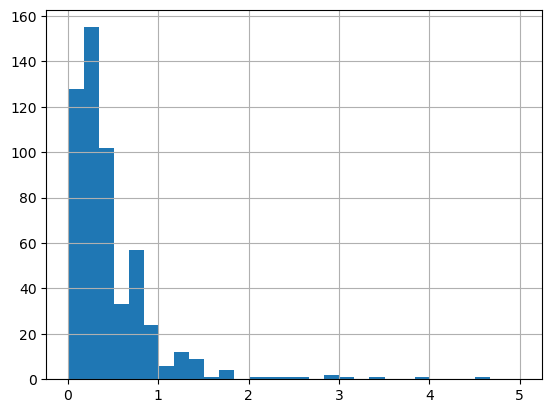

In [54]:
settles_gdf['nightlights'].hist(bins=30, range=(0.01, 5))

In [55]:
# Minimum non-zero light value
(settles_gdf['nightlights'][settles_gdf['nightlights'] > 0]).min()

np.float64(0.1)

### Electrification status classification (based on nightlights and distance to grid)

In [56]:
# Updated assignment criteria:
# Assign "electrified" if distance to MV lines is < 0.5 km OR nighttime light radiance 'nightlights' > 0.4
# Assign "likely electrified" if nighttime light radiance 'nightlights' > 0.03
# Otherwise assign "un-electrified"

MV_dist_thres_very_close = 0.5
mean_light_thres_high = 0.4
mean_light_thres_moderate = 0.03

def assign_elec_status(row):
    if (row["MV_linesDist"] < MV_dist_thres_very_close) or (row['nightlights'] > mean_light_thres_high):
        return "electrified"
    elif row['nightlights'] > mean_light_thres_moderate:
        return "likely electrified"
    else:
        return "un-electrified"

# Apply the updated function row-wise
settles_gdf["Electrification status nightlights"] = settles_gdf.apply(assign_elec_status, axis=1)


In [57]:
print('Number of settlements by electrification classification:')
print(settles_gdf['Electrification status nightlights'].value_counts())
print('\nElectrified population based on the classification above:')
print(settles_gdf.groupby('Electrification status nightlights')['pop_2025'].sum())

Number of settlements by electrification classification:
Electrification status nightlights
un-electrified        13880
electrified             594
likely electrified      248
Name: count, dtype: int64

Electrified population based on the classification above:
Electrification status nightlights
electrified           6362957
likely electrified     465106
un-electrified        5833655
Name: pop_2025, dtype: int64


### IEP electrification status and least-cost electrification mode - if available
(to be modified based on the specific IEP data format)
Including results of a previous Integrated Energy Plan (IEP)
- Electrification status (electrified/unelectrified)
- IEP least cost electrification mode

In [58]:
IEP_elec_gdf=gpd.read_file(IEP_elec_path)

In [59]:
#fix the issue with the ids not matching
IEP_elec_gdf['id']=IEP_elec_gdf['id']+1

In [60]:
settles_gdf = settles_gdf.merge(IEP_elec_gdf[['id', 'IEP Electrification status', 'IEP least-cost electrification mode']], on='id', how='left')

In [61]:
print('Number of settlements by electrification classification (IEP):')
print(settles_gdf['IEP Electrification status'].value_counts())
print('\nElectrified population based on the classification above (IEP):')
print(settles_gdf.groupby('IEP Electrification status')['pop_2025'].sum())

Number of settlements by electrification classification (IEP):
IEP Electrification status
Unelectrified    13833
Electrified        785
Unknown            104
Name: count, dtype: int64

Electrified population based on the classification above (IEP):
IEP Electrification status
Electrified      6680621
Unelectrified    5949038
Unknown            32059
Name: pop_2025, dtype: int64


# Socio-economic

### Extracting RWI to clusters

It requires to rasterize the csv RWI file (as from HDX source) using the provided auxiliary jupyter notebook in the repo

In [62]:
method = 'mean'
col_name = 'rwi'
path= rwi_path

settles_gdf = run_zonal_stats_clipped(
    polygons_gdf=settles_gdf,
    raster_path=path,
    stats=method,
    col_prefix=col_name,
    fill_na=None
)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")

Calculating raster window and reading only relevant data...
Data array shape read: (617, 331)
Running zonal statistics on the clipped array...
Number of NaNs: 1135


### Extracting Food Insecurity % to clusters

Food insecurity is accounted for by assigning to each settlement the percentage of people suffering from high food insecurity in the belonging district. The data is the latest availble from the IPC Acute Food Insecurity (IPC AFI) initiative, which monitors the different levels of severity of acute food insecurity at sub-national level: 

- 1: Minimal/None 
- 2: Stressed 
- 3: Crisis 
- 4: Emergency 
- 5: Catastrophe/Famine 

With a spatial resolution down to the district level, the model utilizes the percentage of the population impacted by a severity grade of 3 or above as an indicator of food insecurity. 

The areas not included in the analysis are be assumed to have no food insecurity. 

In [63]:
food_gdf = gpd.read_file(food_sec_path)

In [64]:
#Extraction done using a spatial join with the largest overlap criterium, instead of mapping admin2 names
settles_gdf = spatial_join_largest_overlap(
    settlements_gdf=settles_gdf, 
    area_gdf=food_gdf, 
    area_value_column='p3_plus_C_population_percentage', 
    new_column_name='food_insec_perc')
#check results
settles_gdf['food_insec_perc'].value_counts(dropna=False)

food_insec_perc
NaN     10754
0.15     1070
0.10     1050
0.05      881
0.25      551
0.20      221
0.35       98
0.30       97
Name: count, dtype: int64

### Livelihood Zone

In [65]:
livel_gdf = gpd.read_file(livel_path)

In [66]:
#Extraction done using a spatial join with the largest overlap criterium, instead of mapping admin2 names
settles_gdf = spatial_join_largest_overlap(
    settlements_gdf=settles_gdf, 
    area_gdf=livel_gdf, 
    area_value_column='LZNAMEEN', 
    new_column_name='livelihoods')
#check results
settles_gdf['livelihoods'].value_counts(dropna=False)

livelihoods
North: vanilla, clove, coconut tree                            1648
Central Iarivo: rice, market gardening, eucalyptus             1475
Ankaratra: staple crops, horticulture, milk                    1296
Toamasina: cloves, coffee, trade                                844
Southeast: coffee, litchi, cassava                              817
Agropastoral midwest: rice, maize, pulses                       803
Northern highland: rice, zebu                                   765
Southern highlands: staple crops, crafts, market gardening      741
High rice and onions production                                 691
Sofia River basin: tobacco, onion, fishing                      592
Aloatra: rice, fishing, livestock rearing                       552
Corridor: forest products, banana                               523
Southwest: rice, lima bean                                      512
Center-east: litchi, coffee, citrus                             479
Betsiboka Delta: rice, fishing      

### Conflict incidents

In [67]:
conflicts_gdf = gpd.read_file(conflict_path)

In [68]:
# Convert to a GeoDataFrame with point geometries
conflicts_gdf = gpd.GeoDataFrame(conflicts_gdf, geometry=gpd.points_from_xy(conflicts_gdf['longitude'], conflicts_gdf['latitude']),crs="EPSG:4326")
conflicts_gdf['fatalities'] = pd.to_numeric(conflicts_gdf['fatalities'], errors='coerce').fillna(0).astype(int)

In [69]:
##Count of fatalities within each settlement's 10km buffer, based on ACLED data (last 2 years)
# 1. Reproject both GeoDataFrames to the provided projected CRS (crs_proj)
settles_proj = settles_gdf.to_crs(crs_proj)
conflict_proj = conflicts_gdf.to_crs(crs_proj)

# 2. Buffer each polygon by 10km
settles_proj['buffered_geom'] = settles_proj.geometry.buffer(10000)

# 3. Spatial join to count fatalities within each buffer
# Prepare buffered polygons GeoDataFrame for the join
buffers_gdf = settles_proj[['buffered_geom']].copy()
buffers_gdf = buffers_gdf.set_geometry('buffered_geom')

# Join conflict points to the buffers
join = gpd.sjoin(conflict_proj, buffers_gdf, how='inner', predicate='within')

# 4. Sum fatalities for each buffer
fatalities_count = join.groupby(join.index_right)['fatalities'].sum()

# 5. Add fatalities count to the original settles_gdf
settles_gdf['conflict_fatalities_last_2y'] = settles_gdf.index.map(fatalities_count).fillna(0).astype(int)


# Environmental 

### Elevation

In [70]:
method = 'mean'
col_name = 'elevation'
path= elevation_path

settles_gdf = run_zonal_stats_clipped(
    polygons_gdf=settles_gdf,
    raster_path=path,
    stats=method,
    col_prefix=col_name,
    fill_na=None
)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")

Calculating raster window and reading only relevant data...
Data array shape read: (48664, 26098)
Running zonal statistics on the clipped array...
Number of NaNs: 0


In [71]:
settles_gdf['elevation']=settles_gdf['elevation'].round(0).astype('Int64')

### Estimating Average Temperature and Cooling Degree Days

In [72]:
method = 'mean'
col_name = 'annual_avg_temp'
path= temperature_annual_avg_path

settles_gdf = run_zonal_stats_clipped(
    polygons_gdf=settles_gdf,
    raster_path=path,
    stats=method,
    col_prefix=col_name,
    fill_na=None
)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")

settles_gdf[col_name] = settles_gdf[col_name].round(1)
## Extracting Cooling Degree Days (as per equation suggested in the methodology)
settles_gdf["CDD_4C"] = ((settles_gdf["annual_avg_temp"] - 4)*365).round()

Calculating raster window and reading only relevant data...
Data array shape read: (1622, 870)
Running zonal statistics on the clipped array...
Number of NaNs: 0


In [73]:
settles_gdf['CDD_4C']=settles_gdf['CDD_4C'].round(0).astype('Int64')

### Extracting HD30 parameter (historical & projection)

Number of Hot Days (Tmax >= 30°C)

In [74]:
method = 'mean'
col_name = 'hot_days_above_30'
path= hot_days_path

settles_gdf = run_zonal_stats_clipped(
    polygons_gdf=settles_gdf,
    raster_path=path,
    stats=method,
    col_prefix=col_name,
    fill_na=None
)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")

Calculating raster window and reading only relevant data...
Data array shape read: (135, 72)
Running zonal statistics on the clipped array...
Number of NaNs: 1546


In [75]:
settles_gdf['hot_days_above_30']=settles_gdf['hot_days_above_30'].round(0).astype('Int64')

### Extracting Relative humidity parameter (historical)

In [76]:
method = 'mean'
col_name = 'rel_humidity'
path= rel_humidity_path

settles_gdf = run_zonal_stats_clipped(
    polygons_gdf=settles_gdf,
    raster_path=path,
    stats=method,
    col_prefix=col_name,
    fill_na=None
)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")

Calculating raster window and reading only relevant data...
Data array shape read: (54, 29)
Running zonal statistics on the clipped array...
Number of NaNs: 1


In [77]:
settles_gdf['rel_humidity']=settles_gdf['rel_humidity'].round(0).astype('Int64')

### Extracting Precipitation parameter (historical)

In [78]:
method = 'mean'
col_name = 'precipitation_mm'
path= precipitation_path

settles_gdf = run_zonal_stats_clipped(
    polygons_gdf=settles_gdf,
    raster_path=path,
    stats=method,
    col_prefix=col_name,
    fill_na=None
)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")

Calculating raster window and reading only relevant data...
Data array shape read: (1622, 870)
Running zonal statistics on the clipped array...
Number of NaNs: 60


In [79]:
settles_gdf['precipitation_mm']=settles_gdf['precipitation_mm'].round(0).astype('Int64')

### Extracting PVout parameter

In [80]:
method = 'mean'
col_name = 'pvout'
path= pvout_path

settles_gdf = run_zonal_stats_clipped(
    polygons_gdf=settles_gdf,
    raster_path=path,
    stats=method,
    col_prefix=col_name,
    fill_na=None
)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")

settles_gdf[col_name]=settles_gdf[col_name].round(0).astype('Int64')

Calculating raster window and reading only relevant data...
Data array shape read: (1622, 870)
Running zonal statistics on the clipped array...
Number of NaNs: 0


### Mean diurnal range (mean of monthly (max temp - min temp)) 

In [81]:
method = 'mean'
col_name = 'mean_diurnal_temp_range'
path= diurnal_range_path

settles_gdf = run_zonal_stats_clipped(
    polygons_gdf=settles_gdf,
    raster_path=path,
    stats=method,
    col_prefix=col_name,
    fill_na=None
)

#Apply the scale factor to bring values back to degrees celsius
settles_gdf[col_name]=((settles_gdf[col_name])*0.1).round(1)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")


Calculating raster window and reading only relevant data...
Data array shape read: (1622, 870)
Running zonal statistics on the clipped array...
Number of NaNs: 60


### Cyclone hazard

In [82]:
method = 'mean'
col_name = 'cyclonHaz_1in100_wind_kmh'
path= cycl_haz_path

settles_gdf = run_zonal_stats_clipped(
    polygons_gdf=settles_gdf,
    raster_path=path,
    stats=method,
    col_prefix=col_name,
    fill_na=None
)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")

settles_gdf[col_name]=settles_gdf[col_name].round(0).astype('Int64')

Calculating raster window and reading only relevant data...
Data array shape read: (50, 27)
Running zonal statistics on the clipped array...
Number of NaNs: 0


### Aridity

In [83]:
method = 'mean'
col_name = 'aridity_index'
path= aridity_path

settles_gdf = run_zonal_stats_clipped(
    polygons_gdf=settles_gdf,
    raster_path=path,
    stats=method,
    col_prefix=col_name,
    fill_na=None
)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")

#Apply the scale factor to bring values back to the correct values
settles_gdf['aridity_index']=(settles_gdf['aridity_index']*0.0001).round(2)

Calculating raster window and reading only relevant data...
Data array shape read: (1622, 870)
Running zonal statistics on the clipped array...
Number of NaNs: 26


### Climatic zones (Koppen Geiger)

In [84]:
method = 'max'
col_name = 'climate_class'
path= clim_class_path

settles_gdf = run_zonal_stats_clipped(
    polygons_gdf=settles_gdf,
    raster_path=path,
    stats=method,
    col_prefix=col_name,
    fill_na=None
)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")

# Create a dictionary mapping from value to description
climate_dict = {
    1:  "Af   Tropical, rainforest",
    2:  "Am   Tropical, monsoon",
    3:  "Aw   Tropical, savannah",
    4:  "BWh  Arid, desert, hot",
    5:  "BWk  Arid, desert, cold",
    6:  "BSh  Arid, steppe, hot",
    7:  "BSk  Arid, steppe, cold",
    8:  "Csa  Temperate, dry summer, hot summer",
    9:  "Csb  Temperate, dry summer, warm summer",
    10: "Csc  Temperate, dry summer, cold summer",
    11: "Cwa  Temperate, dry winter, hot summer",
    12: "Cwb  Temperate, dry winter, warm summer",
    13: "Cwc  Temperate, dry winter, cold summer",
    14: "Cfa  Temperate, no dry season, hot summer",
    15: "Cfb  Temperate, no dry season, warm summer",
    16: "Cfc  Temperate, no dry season, cold summer",
    17: "Dsa  Cold, dry summer, hot summer",
    18: "Dsb  Cold, dry summer, warm summer",
    19: "Dsc  Cold, dry summer, cold summer",
    20: "Dsd  Cold, dry summer, very cold winter",
    21: "Dwa  Cold, dry winter, hot summer",
    22: "Dwb  Cold, dry winter, warm summer",
    23: "Dwc  Cold, dry winter, cold summer",
    24: "Dwd  Cold, dry winter, very cold winter",
    25: "Dfa  Cold, no dry season, hot summer",
    26: "Dfb  Cold, no dry season, warm summer",
    27: "Dfc  Cold, no dry season, cold summer",
    28: "Dfd  Cold, no dry season, very cold winter",
    29: "ET   Polar, tundra",
    30: "EF   Polar, frost"
}

# Replace numeric climate class values with their descriptions
settles_gdf['climate_class'] = settles_gdf['climate_class'].map(climate_dict)
settles_gdf.head()

Calculating raster window and reading only relevant data...
Data array shape read: (1622, 870)
Running zonal statistics on the clipped array...
Number of NaNs: 26


,building_count,type,geometry,id,settl_area_km2,Region,District,Commune,Fokontany,pop_2025,...,annual_avg_temp,CDD_4C,hot_days_above_30,rel_humidity,precipitation_mm,pvout,mean_diurnal_temp_range,cyclonHaz_1in100_wind_kmh,aridity_index,climate_class
0,293,Small Settlement Area,"POLYGON ((704951.258 1554922.511, 705139.444 1...",24,0.154384,Diana,Antsiranana II,Andranovondronina,Andranovondronina,166,...,25.3,7774,<NA>,72,1132,1805,7.6,205,0.54,"Aw Tropical, savannah"
1,120,Small Settlement Area,"POLYGON ((710199.07 1553934.387, 710241.316 15...",41,0.102011,Diana,Antsiranana II,Andranovondronina,Bedarabe,79,...,25.7,7920,<NA>,72,1126,1804,7.5,205,0.52,"Aw Tropical, savannah"
2,936,Small Settlement Area,"POLYGON ((716545.241 1532842.016, 716641.534 1...",118,0.999533,Diana,Antsiranana II,Ramena,Ramena,1762,...,25.9,7993,52,72,1139,1796,7.8,205,0.52,"Aw Tropical, savannah"
3,115,Small Settlement Area,"POLYGON ((727137.236 1518417.974, 727267.62 15...",173,0.160230,Diana,Antsiranana II,Mahavanona,Ambodivahibe,90,...,25.2,7738,<NA>,76,1187,1776,8.1,207,0.54,"Aw Tropical, savannah"
4,254,Small Settlement Area,"POLYGON ((734776.34 1510755.427, 734738.632 15...",253,0.346018,Diana,Antsiranana II,Andrafiabe,Ambolobozokely,212,...,24.9,7628,<NA>,78,1212,1780,8.2,209,0.54,"Aw Tropical, savannah"


# Accessibility

**Note!** Accessibility maps can be retrieved using the other notebookes in this repository. More specifically:
* "Travel_time_maps.ipynb" will prepare the vector data as needed for
* "R-tool.ipynb", which prepares uses the [motorized friction surface layer](https://malariaatlas.org/project-resources/accessibility-to-healthcare/) and generates travel time maps for the locations of airports, ports, railways, major cities and the capital located in the "key_locations_for_Distance directory".

The above notebooks are preparatory and should be run before running this current .ipynb.

In [85]:
settles_gdf=run_zonal_stats_clipped(settles_gdf,tt_airports_path,'mean','travel_time_airports',fill_na=None)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")
settles_gdf=run_zonal_stats_clipped(settles_gdf,tt_ports_path,'mean','travel_time_ports',fill_na=None)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")
settles_gdf=run_zonal_stats_clipped(settles_gdf,tt_cities_path,'mean','travel_time_cities',fill_na=None)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")
settles_gdf=run_zonal_stats_clipped(settles_gdf,tt_capital_path,'mean','travel_time_capital',fill_na=None)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")
settles_gdf=run_zonal_stats_clipped(settles_gdf,tt_railways_path,'mean','travel_time_railways',fill_na=None)
print(f"Number of NaNs: {settles_gdf[col_name].isnull().sum()}")
#Convert minutes to hours
settles_gdf['travel_time_airports']= (settles_gdf['travel_time_airports']/60).round(1)
settles_gdf['travel_time_ports'] = (settles_gdf['travel_time_ports'] / 60).round(1)
settles_gdf['travel_time_cities'] = (settles_gdf['travel_time_cities'] / 60).round(1)
settles_gdf['travel_time_capital'] = (settles_gdf['travel_time_capital'] / 60).round(1)
settles_gdf['travel_time_railways'] = (settles_gdf['travel_time_railways'] / 60).round(1)
settles_gdf.head()

Calculating raster window and reading only relevant data...
Data array shape read: (1622, 870)
Running zonal statistics on the clipped array...
Number of NaNs: 26
Calculating raster window and reading only relevant data...
Data array shape read: (1622, 870)
Running zonal statistics on the clipped array...
Number of NaNs: 26
Calculating raster window and reading only relevant data...
Data array shape read: (1622, 870)
Running zonal statistics on the clipped array...
Number of NaNs: 26
Calculating raster window and reading only relevant data...
Data array shape read: (1622, 870)
Running zonal statistics on the clipped array...
Number of NaNs: 26
Calculating raster window and reading only relevant data...
Data array shape read: (1622, 870)
Running zonal statistics on the clipped array...
Number of NaNs: 26


,building_count,type,geometry,id,settl_area_km2,Region,District,Commune,Fokontany,pop_2025,...,pvout,mean_diurnal_temp_range,cyclonHaz_1in100_wind_kmh,aridity_index,climate_class,travel_time_airports,travel_time_ports,travel_time_cities,travel_time_capital,travel_time_railways
0,293,Small Settlement Area,"POLYGON ((704951.258 1554922.511, 705139.444 1...",24,0.154384,Diana,Antsiranana II,Andranovondronina,Andranovondronina,166,...,1805,7.6,205,0.54,"Aw Tropical, savannah",1.2,1.1,20.7,26.3,22.5
1,120,Small Settlement Area,"POLYGON ((710199.07 1553934.387, 710241.316 15...",41,0.102011,Diana,Antsiranana II,Andranovondronina,Bedarabe,79,...,1804,7.5,205,0.52,"Aw Tropical, savannah",1.3,1.1,20.8,26.3,22.5
2,936,Small Settlement Area,"POLYGON ((716545.241 1532842.016, 716641.534 1...",118,0.999533,Diana,Antsiranana II,Ramena,Ramena,1762,...,1796,7.8,205,0.52,"Aw Tropical, savannah",0.4,0.3,19.9,25.5,21.7
3,115,Small Settlement Area,"POLYGON ((727137.236 1518417.974, 727267.62 15...",173,0.160230,Diana,Antsiranana II,Mahavanona,Ambodivahibe,90,...,1776,8.1,207,0.54,"Aw Tropical, savannah",0.8,0.9,19.8,25.4,21.6
4,254,Small Settlement Area,"POLYGON ((734776.34 1510755.427, 734738.632 15...",253,0.346018,Diana,Antsiranana II,Andrafiabe,Ambolobozokely,212,...,1780,8.2,209,0.54,"Aw Tropical, savannah",0.8,1.0,19.5,25.2,21.3


# Distance to Coastlines for marine fishing

In [86]:
## Read shores as gdf
shores_gdf = gpd.read_file(shorelines_path)

In [87]:
import leafmap
m = leafmap.Map()
m.add_gdf(shores_gdf,layer_name="Shorelines")
#m.add_gdf(settles_gdf,layer_name="Settlements")
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [88]:
settles_gdf_copy=settles_gdf
settles_gdf_copy=distance_from_lines('shoreline',adm0_gdf.buffer(0.1),crs_proj,settles_gdf_copy,shorelines_path)
settles_gdf_copy['shorelineDist']=settles_gdf_copy['shorelineDist'].round(1)
settles_gdf_copy.rename(columns={'shorelineDist': 'shoreline_dist'}, inplace=True)


--- Starting analysis for shoreline at 2025-12-07 18:28:25.922220 ---
Preparing settlements...
Reading and processing lines...
Discretizing lines into points (100m intervals)...
Running KDTree algorithm...
Checking for exact physical overlaps...
--- Finished shoreline. Duration: 0:00:03.561233 ---


In [89]:
settles_gdf=settles_gdf_copy

# Inland water occurance for inland fishing

In [90]:
## Adding a 10km buffer to the settlements layer
settles_gdf_buf = settles_gdf.copy()
settles_gdf_buf_prj = settles_gdf_buf.to_crs(crs_proj)
settles_gdf_buf_prj['geometry'] = settles_gdf_buf_prj.apply(lambda x:
                                                            x.geometry.buffer(10000, cap_style=3), axis=1)  ### ~10000m#
settles_gdf_buf = settles_gdf_buf_prj.to_crs(crs_WGS84)

In [91]:
# Calculate overlap areas where raster pixel value = 3
settles_gdf_buf = calculate_raster_overlap_area_ha(water_occurrance_path, settles_gdf_buf, crs_WGS84, crs_proj, value_to_check=3)
settles_gdf_copy = settles_gdf.merge(
    settles_gdf_buf[['id', 'overlap_area_ha']],
    on='id',
    how='left'
)
settles_gdf = settles_gdf_copy.rename(columns={'overlap_area_ha': 'permanent_water_within10km'})
settles_gdf['permanent_water_within10km']=settles_gdf['permanent_water_within10km'].round(1)


# Extracting extensive Ag data into influence areas (Voronoi)

## Creation of influence areas (voronoi polygons)
Choose whether create voronoi polygons' geometries from scratch or load the pre-calculated dataset, by uncommenting the respective line below:

In [92]:
## Uncomment this to create voronoi polygons (first run or if they need to be created again)
voronoi_method= 'create' 

## Uncomment this to load the voronoi polygons from 'data/processed/input_voronoi' (to use the pre-calculated ones)
#voronoi_method= 'read' 

In [94]:
if voronoi_method == 'create':
    vor_poly = createVoronoi_3(admin_gdf_buf, settles_gdf, crs_proj, crs_WGS84,boundary_point_spacing=100, simplify_settlements=True)
    # Save the newly created dataset to folder
    vor_poly.to_file(project_root / f"data/processed/vor_poly_{datetime.now().strftime('%Y%m%d_%H%M%S')}.gpkg", driver="GPKG")
else:
    vor_poly_path = get_single_input_file_path(
    project_root/'data/processed/input_voronoi',
    allowed_extensions=MASTER_VECTOR_EXTENSIONS)

    vor_poly=gpd.read_file(vor_poly_path)


Simplifying admin boundary with tolerance=100 meters...
Admin boundary simplified.
Boundary area defined with 49672 boundary points spaced 100 meters apart.
Simplifying settlement geometries with tolerance=100 meters...
Settlement geometries simplified.
Processed 1200 perimeter vertices so far...
Processed 1500 perimeter vertices so far...
Processed 2300 perimeter vertices so far...
Processed 4700 perimeter vertices so far...
Processed 5400 perimeter vertices so far...
Processed 6900 perimeter vertices so far...
Processed 8000 perimeter vertices so far...
Processed 8100 perimeter vertices so far...
Processed 8900 perimeter vertices so far...
Processed 9000 perimeter vertices so far...
Processed 11300 perimeter vertices so far...
Processed 12500 perimeter vertices so far...
Processed 13700 perimeter vertices so far...
Processed 16300 perimeter vertices so far...
Processed 16500 perimeter vertices so far...
Processed 16900 perimeter vertices so far...
Processed 18100 perimeter vertices s

## Extracting Cropland extent

In [99]:
vor_poly = process_categorical_raster(vor_poly, cropland_path, "cropland_")

Starting cropland_ extraction at 2025-12-07 19:23:31.193397
cropland_ processing completed at 2025-12-07 19:33:56.949250


In [100]:
# 1. Identify land cover columns using a list comprehension
# This replaces the 4-line for-loop you had.
crop_cols = [col for col in vor_poly.columns if "cropland" in col]

# 2. Validation
if not crop_cols:
    print("There are not any Land Cover associated columns; please revise")
else:
    print(f"Found {len(crop_cols)} cropland categories: {crop_cols}")

Found 2 cropland categories: ['cropland_0', 'cropland_1']


In [101]:
vor_poly = calc_Crop_sqkm(vor_poly, crop_cols)
vor_poly.rename({'cropland_0':'No_crop_ha', 'cropland_1':'Cropland_ha'}, axis=1, inplace=True)
vor_poly["Crop%"] = vor_poly['Cropland_ha']/vor_poly['Vor_area_ha']*100

## Extracting production of perishable crops among the SPAM crop categories

In [102]:
crop_list = {
    'Banana': 'BANA_A',
    'Cassava': 'CASS_A',
    'Citrus': 'CITR_A',
    'Cowpea': 'COWP_A',
    'Other_Roots': 'ORTS_A',
    'Other_Tropical_Fruit': 'TROF_A',
    'Other_Vegetables': 'VEGE_A',
    'Potato': 'POTA_A',
    'Sweet_Potato': 'SWPO_A',
    'Temperate_Fruit': 'TEMF_A',
    'Tomato': 'TOMA_A'
}

# This creates a dictionary: {'BANA_A': 'full/path/to/BANA_A.tif', ...}
all_files = os.listdir(crop_prod_folder_path)
file_map = {}

for file_code in crop_list.values():
    # Find the file that matches the code
    match = next((f for f in all_files if file_code in f and f.endswith('.tiff')), None)
    if match:
        file_map[file_code] = os.path.join(crop_prod_folder_path, match)

print(f"Found {len(file_map)} raster files. Starting extraction...")

# 2. RUN THE LOOP
for crop, file_code in crop_list.items():
    
    # Check if we found the file
    raster_path = file_map.get(file_code)
    
    if not raster_path:
        print(f"Skipping {crop} ({file_code}): File not found.")
        continue

    # Construct the column name as desired (can be changed)
    target_col_name = f"{crop}_prod_t_year"
    
    print(f"Processing {crop}...")

    try:
        # CALL YOUR FUNCTION HERE
        vor_poly = run_zonal_stats_clipped(
            polygons_gdf=vor_poly, 
            raster_path=raster_path, 
            stats=['sum'],
            col_prefix=target_col_name, 
            fill_na=0
        )
        

    except Exception as e:
        print(f"Error processing {crop}: {e}")

print("Processing complete.")

Found 11 raster files. Starting extraction...
Processing Banana...
Calculating raster window and reading only relevant data...
Data array shape read: (3281, 1758)
Running zonal statistics on the clipped array...
Processing Cassava...
Calculating raster window and reading only relevant data...
Data array shape read: (3281, 1758)
Running zonal statistics on the clipped array...
Processing Citrus...
Calculating raster window and reading only relevant data...
Data array shape read: (3281, 1758)
Running zonal statistics on the clipped array...
Processing Cowpea...
Calculating raster window and reading only relevant data...
Data array shape read: (3281, 1758)
Running zonal statistics on the clipped array...
Processing Other_Roots...
Calculating raster window and reading only relevant data...
Data array shape read: (3281, 1758)
Running zonal statistics on the clipped array...
Processing Other_Tropical_Fruit...
Calculating raster window and reading only relevant data...
Data array shape read: 

## Merging Voronoi to clusters

In [103]:
vor_poly = vor_poly.reset_index()
vor_poly['uid']= vor_poly['uid'].astype(int)

In [104]:
# Ensure Key Consistency
settles_gdf['id'] = settles_gdf['id'].astype(int)
vor_poly['uid'] = vor_poly['uid'].astype(int)

# Unified Merge
settles_gdf = settles_gdf.merge(
    vor_poly.drop(columns={'geometry','uniqueID','Vor_area_sq.km','Vor_area_ha','No_crop_ha'}), 
    how='left', 
    left_on='id', 
    right_on='uid'
)

# Cleanup
settles_gdf.drop(columns=['uid'], inplace=True, errors='ignore')

Summary table describing the dataset

In [105]:
# Drop geometry column for stats
df = settles_gdf.drop(columns='geometry')

# Descriptive stats
summary_table = df.describe(include='all')

# Data types row
dtypes_row = df.dtypes.to_frame().T
dtypes_row.index = ['dtype']

# Count NaNs per column
nan_counts = df.isna().sum().to_frame().T
nan_counts.index = ['NaN_count']

# Count zeros per column (only numeric columns to avoid errors)
zero_counts = df.select_dtypes(include=['number']).eq(0).sum().to_frame().T
zero_counts.index = ['zero_count']

# For non-numeric columns, add zero counts as 0
non_numeric_cols = set(df.columns) - set(zero_counts.columns)
for col in non_numeric_cols:
    zero_counts[col] = 0
zero_counts = zero_counts[df.columns]  # reorder to original column order

# Count infinity values (both +inf and -inf) per column (only numeric)
inf_counts = df.select_dtypes(include=['number']).isin([np.inf, -np.inf]).sum().to_frame().T
inf_counts.index = ['inf_count']

# For non-numeric columns, add inf counts as 0
for col in set(df.columns) - set(inf_counts.columns):
    inf_counts[col] = 0
inf_counts = inf_counts[df.columns]  # reorder to original column order

# Combine all rows
summary_with_extra = pd.concat([summary_table, dtypes_row, nan_counts, zero_counts, inf_counts], axis=0)

pd.set_option('display.max_columns', None)
summary_with_extra


,building_count,type,id,settl_area_km2,Region,District,Commune,Fokontany,pop_2025,pop_dens_pp_km2,pop_20km,MV_linesDist,MGDist,nightlights,Electrification status nightlights,IEP Electrification status,IEP least-cost electrification mode,rwi,food_insec_perc,livelihoods,conflict_fatalities_last_2y,elevation,annual_avg_temp,CDD_4C,hot_days_above_30,rel_humidity,precipitation_mm,pvout,mean_diurnal_temp_range,cyclonHaz_1in100_wind_kmh,aridity_index,climate_class,travel_time_airports,travel_time_ports,travel_time_cities,travel_time_capital,travel_time_railways,shoreline_dist,permanent_water_within10km,Cropland_ha,Crop%,Banana_prod_t_year,Cassava_prod_t_year,Citrus_prod_t_year,Cowpea_prod_t_year,Other_Roots_prod_t_year,Other_Tropical_Fruit_prod_t_year,Other_Vegetables_prod_t_year,Potato_prod_t_year,Sweet_Potato_prod_t_year,Temperate_Fruit_prod_t_year,Tomato_prod_t_year
count,14722.0,14722,14722.0,14722.0,14717,14717,14717,14717,14722.0,14722.0,14722.0,14722.0,14722.0,14722.0,14722,14722,14722,13587.0,3968.0,14719,14722.0,14722.0,14722.0,14722.0,13176.0,14721.0,14662.0,14722.0,14662.0,14722.0,14696.0,14696,14720.0,14720.0,14720.0,14720.0,14720.0,14722.0,14722.0,14721.0,14721.0,14721.0,14721.0,14721.0,14721.0,14721.0,14721.0,14721.0,14721.0,14721.0,14721.0,14721.0
unique,<NA>,2,NaN,NaN,22,115,1373,6803,NaN,NaN,NaN,NaN,NaN,NaN,3,3,5,NaN,NaN,27,NaN,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,NaN,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,<NA>,Small Settlement Area,NaN,NaN,Sofia,Fenerive Est,Morafeno,Morafeno,NaN,NaN,NaN,NaN,NaN,NaN,un-electrified,Unelectrified,SHS,NaN,NaN,"North: vanilla, clove, coconut tree",NaN,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,NaN,"Aw Tropical, savannah",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,<NA>,14594,NaN,NaN,1358,357,77,61,NaN,NaN,NaN,NaN,NaN,NaN,13880,13833,7243,NaN,NaN,1648,NaN,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,NaN,3678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,420.956731,NaN,265063.908097,0.345847,NaN,NaN,NaN,NaN,860.054205,1727.149097,180716.903682,49.320934,32.031769,0.020554,NaN,NaN,NaN,-0.381968,0.139844,NaN,0.913938,570.915161,22.00483,6571.771634,79.982544,74.519054,1566.048834,1685.79894,11.573237,186.976973,0.944939,NaN,2.440333,6.170978,7.631834,12.248077,7.765414,88.908226,203.051562,107.914854,8.68903,31.532199,216.222546,8.253522,2.073745,18.987664,59.190395,33.508097,22.686733,91.496223,4.02798,3.351593
std,6556.292115,NaN,152508.499882,2.776673,NaN,NaN,NaN,NaN,16862.172962,894.519449,363118.959614,42.763146,26.14369,0.244558,NaN,NaN,NaN,0.2625,0.076459,NaN,2.01893,546.911258,3.094849,1129.607165,103.882311,8.503671,612.794565,154.353451,2.227202,15.625494,0.434898,NaN,2.227343,3.457444,5.497183,7.534801,6.258669,67.470376,615.865594,277.098456,14.992339,67.470875,510.808599,14.736089,4.52527,33.371511,327.172855,68.527926,107.467332,309.084758,8.371947,6.213902
min,100.0,NaN,24.0,0.026731,NaN,NaN,NaN,NaN,0.0,0.0,545.0,0.007037,0.006769,0.0,NaN,NaN,NaN,-1.3,0.05,NaN,0.0,-1.0,13.6,3504.0,0.0,55.0,338.0,1238.0,5.5,158.0,0.2,NaN,0.0,0.0,0.1,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,127.0,NaN,130355.5,0.119346,NaN,NaN,NaN,NaN,170.0,1102.25,43164.75,12.484455,13.559232,0.0,NaN,NaN,NaN,-0.6,0.1,NaN,0.0,62.0,19.6,5694.0,4.0,67.0,1283.0,1542.0,9.825,175.0,0.68,NaN,1.0,3.4,2.5,5.2,1.8,24.4,0.4,5.350894,0.249936,3.0,9.7,1.6,0.2,1.0,0.0,4.2,0.0,1.9,0.6,0.5
50%,175.0,NaN,256504.0,0.187245,NaN,NaN,NaN,NaN,279.0,1524.0,90518.0,37.725716,24.917882,0.0,NaN,NaN,NaN,-0.4,0.15,NaN,0.0,371.0,22.3,6680.0,25.0,74.0,1489.0,1712.0,11.7,183.0,0.89,NaN,1.9,6.2,6.5,12.0,6.6,82.6,27.55,36.752583,2.183686,12.1,60.9,4.0,0.7,8.5,0.1,14.0,0.0,14.6,1.5,1.6
75%,291.0,NaN,400003.75,0.310264,NaN,NaN,NaN,NaN,506.0,2123.75,179044.25,78.769447,42.789762,0.0,NaN,NaN,NaN,-0.2,0.15,NaN,1.0,1018.0,24.1,7337.0,140.0,82.0,1894.0,1826.0,13.0,200.0,1.2,NaN,3.1,8.4,12.4,

In [106]:
# Drop columns only if they exist in the dataframe
columns_to_drop = [ 'building_area',  'type',  'settl_area_km2',  'building_area_perc', 'uid',  'uniqueID',  'No_crop_ha']
settles_gdf = settles_gdf.drop(columns=[col for col in columns_to_drop if col in settles_gdf.columns])

In [107]:
settles_gdf = settles_gdf.to_crs(epsg=4326)

In [108]:
settles_gdf.columns

Index(['building_count', 'geometry', 'id', 'Region', 'District', 'Commune',
       'Fokontany', 'pop_2025', 'pop_dens_pp_km2', 'pop_20km', 'MV_linesDist',
       'MGDist', 'nightlights', 'Electrification status nightlights',
       'IEP Electrification status', 'IEP least-cost electrification mode',
       'rwi', 'food_insec_perc', 'livelihoods', 'conflict_fatalities_last_2y',
       'elevation', 'annual_avg_temp', 'CDD_4C', 'hot_days_above_30',
       'rel_humidity', 'precipitation_mm', 'pvout', 'mean_diurnal_temp_range',
       'cyclonHaz_1in100_wind_kmh', 'aridity_index', 'climate_class',
       'travel_time_airports', 'travel_time_ports', 'travel_time_cities',
       'travel_time_capital', 'travel_time_railways', 'shoreline_dist',
       'permanent_water_within10km', 'Cropland_ha', 'Crop%',
       'Banana_prod_t_year', 'Cassava_prod_t_year', 'Citrus_prod_t_year',
       'Cowpea_prod_t_year', 'Other_Roots_prod_t_year',
       'Other_Tropical_Fruit_prod_t_year', 'Other_Vegetables_pro

# Export/save

In [109]:
## Export settlements to geopackage
settles_gdf.to_file(project_root / f"data/processed/settlements_extracted{datetime.now().strftime('%Y%m%d_%H%M%S')}.gpkg", driver="GPKG")

Export CSV with X and Y columns representing the settlement's centroid, as well as with a WKT geometry column

In [ ]:
# export_df = settles_gdf.copy()

# # Ensure GeoDataFrame is in WGS84 projection (EPSG:4326)
# export_df = export_df.to_crs(epsg=4326)

# # Calculate centroids
# export_df['centroid'] = export_df.geometry.centroid

# # Extract X and Y coordinates from centroids
# export_df['X'] = export_df.centroid.x
# export_df['Y'] = export_df.centroid.y

# # Add WKT column from geometry using shapely wkt attribute
# export_df['WKT'] = export_df.geometry.apply(lambda geom: geom.wkt)

# # Drop original geometry and centroid columns
# export_df.drop(['geometry', 'centroid'], axis=1, inplace=True)

# # Export to CSV
# export_df.to_csv(project_root / f"data/processed/settlements_extracted_{datetime.now().strftime('%Y%m%d_%H%M%S')}.CSV")
